<table class="tfo-notebook-buttons" align="left">
<td style="border: none;">
<a target="blank" href="https://colab.research.google.com/github/Hari31416/Portfolio/blob/main/Titanic/Models_II.ipynb?hl=en"><img src="https://colab.research.google.com/img/colab_favicon_256px.png" width="28" height="28"/>Run on Google Colab</a></td>
<td style="border: none;">
<a target="blank" href="https://github.com/Hari31416/Portfolio/blob/main/Titanic/Models_II.ipynb"><img src="https://cdn.icon-icons.com/icons2/2368/PNG/512/github_logo_icon_143772.png" width="28" height="28"/>View on Github</a></td>
<td style="border: none;">
</table>

# Preparation

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## loading the data

In [2]:
train = pd.read_csv('train_final.csv')
test = pd.read_csv('test_final.csv')

In [3]:
train.head()

,Survived,Pclass,Sex,SibSp,Parch,FamilySize,Embarked_Q,Embarked_S,Title_Master,Title_Miss,...,Ticket_first_letter_7,Ticket_first_letter_X,Cabin_First_B,Cabin_First_C,Cabin_First_D,Cabin_First_E,Cabin_First_F,Cabin_First_N,Age,Fare
0,0,3,0,1,0,2,0,1,0,0,...,0,1,0,0,0,0,0,1,-0.565587,-0.502445
1,1,1,1,1,0,2,0,0,0,0,...,0,1,0,1,0,0,0,0,0.624229,0.786845
2,1,3,1,0,0,1,0,1,0,1,...,0,1,0,0,0,0,0,1,-0.268133,-0.488854
3,1,1,1,1,0,2,0,1,0,0,...,0,0,0,1,0,0,0,0,0.401138,0.420730
4,0,3,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,1,0.401138,-0.486337


In [4]:
test.head()

,Pclass,Sex,SibSp,Parch,FamilySize,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,...,Ticket_first_letter_7,Ticket_first_letter_X,Cabin_First_B,Cabin_First_C,Cabin_First_D,Cabin_First_E,Cabin_First_F,Cabin_First_N,Age,Fare
0,3,0,0,0,1,1,0,0,0,1,...,0,0,0,0,0,0,0,1,0.337221,-0.497350
1,3,1,1,0,2,0,1,0,0,0,...,0,0,0,0,0,0,0,1,1.302134,-0.512214
2,2,0,0,0,1,1,0,0,0,1,...,0,0,0,0,0,0,0,1,2.460031,-0.464037
3,3,0,0,0,1,0,1,0,0,1,...,0,0,0,0,0,0,0,1,-0.241727,-0.482412
4,3,1,1,1,3,0,1,0,0,0,...,0,0,0,0,0,0,0,1,-0.627692,-0.417429


In [5]:
columns = test.columns
columns

Index(['Pclass', 'Sex', 'SibSp', 'Parch', 'FamilySize', 'Embarked_Q',
       'Embarked_S', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs',
       'Title_Other', 'Title_Rev', 'Ticket_first_letter_2',
       'Ticket_first_letter_3', 'Ticket_first_letter_4',
       'Ticket_first_letter_6', 'Ticket_first_letter_7',
       'Ticket_first_letter_X', 'Cabin_First_B', 'Cabin_First_C',
       'Cabin_First_D', 'Cabin_First_E', 'Cabin_First_F', 'Cabin_First_N',
       'Age', 'Fare'],
      dtype='object')

In [6]:
X = train.drop(['Survived'], axis=1).values
y = train['Survived'].values

### Creating the train and test data

In [7]:
len(X)

891

Since there are just 891 rows in the train data, we will use a test size of 0.25 to create the test data.

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [9]:
len(X_train),len(X_test)

(668, 223)

## Modeling

### Procedure

Since we have already standardized the data, we'll jump directly to the model creation. We'll start from the simplest, `LinearRegression` and keep on increasing the complexity until we get a good model. The process will be as follows:
1. Create a model using default parameters
2. Fit the model to the training data and get model performance
3. Create a `GridSearchCV` object to find the best parameters for the model
4. Fit the model to the training data and get model performance
5. Repeat steps 1-4 for different models

Since this is a classification problem, the models we'll use are:
1. `LogisticRegression`
2. `KNeighborsClassifier`
3. `SVC`
4. `DecisionTreeClassifier`
5. `RandomForestClassifier`
6. `GaussianNB`
7. `GradientBoostingClassifier`
8. `XGBClassifier`
9. `BaggingClassifier`
10. `AdaBoostClassifier`
11. `ExtraTreesClassifier`

...and more( if I can find them!).

With every model, I'll briefly describe the parameters that we'll be using. If we created all these models in a single notebook, it will be huge. So I'll create a number of notebooks.

To keeptrack of various models and their performance, I'll create a dictionary with model name as key and a dictionary of performance metrics as values.

### Performance Metrics

In previous notebook, we saw that this classification is not perfectly balanced as only about 39% passengers survived. So `accuracy` is not that good a metric. However, we'll be using accuracy along with `precision`, `recall`, `f1_score` and  `roc_auc_score` to evaluate the model performance. These are the parameters, we'll be saving in the dictionary. We'll also plot the confusion matrix and ROC curve. So, the metrics we'll be saving in the dictionary are:
1. `accuracy`
2. `precision`
3. `recall`
4. `f1_score`
5. `roc_auc_score`

Let's create some helper functions.

### Helper Functions

I'll be using the `shelve` module to save the dictionary. The dictionary is loaded in the code cell below and given the name `models_performance`. 

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report
from life_saving_tools import Notification
from sklearn.model_selection import GridSearchCV
import shelve
n = Notification.Notification()
params = {}

def load_performance_dict(file = 'models_performance'):
    """
    This function loads the performance of a model from the `model_performance` \\
        dictionary.

    Parameters
    ----------
    model_name : string
        the name of the model to load from the `model_performance` dictionary

    Returns
    -------
    model_performance : dictionary
    """
    shelve_file = shelve.open(file)

    try:
        dictionary = shelve_file[file]
    except:
        dictionary = {}

    shelve_file.close()
    return dictionary

models_performance = load_performance_dict('models_performance')
models_on_train = load_performance_dict('models_on_train')

def save_performance_dict(file = 'models_performance', dictionary = models_performance):
    """
    This function saves the model_performance dictionary to a shelve file.

    Parameters
    ----------
    file : string
        the name of the shelve file to save the dictionary to

    Returns
    -------
    None
    """
    shelve_file = shelve.open(file)
    shelve_file[file] = dictionary
    shelve_file.close()

def perform_grid_search(model, params = params, X= X_train, y=y_train, 
    text = False, play = True, cv = 5, scoring = 'roc_auc', **kwargs):
    """
    Performs grid serach on the model and returns the best model with parameters.

    Parameters
    ----------
    model : sklearn model

    X : training data
        defualt is X_train

    y : target data
        defualt is y_train

    params : dictionary
        the parameters to search over
        defualt is params

    text : boolean
        if True, a notification is sent to whatsapp
        defualt is False
    
    play : boolean
        if True, music is played
        defualt is True

    cv : number of folds for cross validation
        defualt is 5

    scoring : scoring metric
        defualt is 'roc_auc'

    verbose : verbosity level
        defualt is 1

    Returns
    -------
    grid_search : sklearn GridSearchCV object
    """
    grid = GridSearchCV(model, params, cv=cv, scoring=scoring, **kwargs)
    grid.fit(X, y)

    best_estimator = grid.best_estimator_
    best_params = grid.best_params_
    best_score = grid.best_score_
    message = f"""Following is the best model and its parameters:\n\
Best Model:\n{best_estimator}\nBest params:\
\n{best_params}\nBest score: {best_score}"""

    if text:
        n.send_whatsapp_text(message)
    
    if play:
        n.play_n_stop()
    print(message)
    return grid

def visualize_model(model, features = X_test, target = y_test):
    """
    This function plots the confusion metrics and classification report

    Parameters
    ----------
    model : sklearn model

    Returns
    -------
    None
    """
    #predicting on the data
    y_pred = model.predict(features)
    
    #Printing the classification report
    print(classification_report(target, y_pred))
    
    #Confusion matrix
    cm = confusion_matrix(target, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.show()

def evaluate_model(model, model_name = None, train = False, final = False, X = X_test, y = y_test):
    """
    The function takes a model as input and creats a dictionary with the model's \\
        accuracy, precision, recall, f1 score, and roc_auc_score and add them to the \\
        `model_performance` dictionary and returns it. The `model_performance` dictionary \\
        is instantiated just before this function is created.

    Parameters
    ----------
    model : sklearn model

    model_name : string
        the name of the model to store as a key in the `model_performance` dictionary

    final : boolean
        if True, the scores are added to the `model_performance` dictionary as well

    Returns
    -------
    model_performance : dictionary
    """
    #Making predictions on the test set
    y_pred = model.predict(X)

    #Getting the metrics
    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    roc_auc = roc_auc_score(y, y_pred)

    if final:
        if train:
            dictionary = models_on_train
            file = "models_on_train"
        else:
            dictionary = models_performance
            file = "models_performance"
    #Adding the metrics to the model_performance dictionary
        if model_name is None:
            model_name = type(model).__name__

        dictionary[model_name] = {
                'accuracy': accuracy, 'precision': precision, 
                'recall': recall, 'f1': f1, 'roc_auc': roc_auc}
        save_performance_dict(file=file, dictionary=dictionary)
        return dictionary[model_name]
    else:
        return {'accuracy': accuracy, 'precision': precision, 
                'recall': recall, 'f1': f1, 'roc_auc': roc_auc}

In [11]:
model_params = shelve.open('model_params')

In [12]:
list(model_params.keys())

['lr_base',
 'lr_final',
 'knc_base',
 'knn_final',
 'svc_base',
 'svc_final',
 'dt_base',
 'dt_final',
 'rf_base',
 'rf_final']

In [11]:
pd.DataFrame(models_performance).T

,accuracy,precision,recall,f1,roc_auc
lr_base,0.802691,0.747253,0.764045,0.755556,0.796202
lr_gs_final,0.820628,0.769231,0.786517,0.777778,0.814900
knc_base,0.816143,0.779070,0.752809,0.765714,0.805509
knn_final,0.838565,0.844156,0.730337,0.783133,0.820392
svc_base,0.834081,0.817073,0.752809,0.783626,0.820434
svc_final,0.825112,0.790698,0.764045,0.777143,0.814858
dt_base,0.811659,0.770115,0.752809,0.761364,0.801778
dt_final,0.829596,0.800000,0.764045,0.781609,0.818590
rf_base,0.816143,0.792683,0.730337,0.760234,0.801736
rf_final,0.820628,0.802469,0.730337,0.764706,0.805467


In [12]:
pd.DataFrame(models_on_train).T

,accuracy,precision,recall,f1,roc_auc
lr_base,0.853293,0.829787,0.770751,0.799180,0.837183
lr_final,0.851796,0.831897,0.762846,0.795876,0.834435
knc_base,0.853293,0.841410,0.754941,0.795833,0.834097
knn_final,0.832335,0.865285,0.660079,0.748879,0.798714
svc_base,0.836826,0.813043,0.739130,0.774327,0.817758
svc_final,0.836826,0.810345,0.743083,0.775258,0.818529
dt_base,0.940120,0.973333,0.865613,0.916318,0.925577
dt_final,0.836826,0.797521,0.762846,0.779798,0.822387
rf_base,0.935629,0.981651,0.845850,0.908705,0.918106
rf_final,0.889222,0.920188,0.774704,0.841202,0.866870


# Boosting Models

## GradientBoostingClassifier

### Default Parameters

In [13]:
from sklearn.ensemble import GradientBoostingClassifier

gbc_base = GradientBoostingClassifier(random_state=101)
gbc_base.fit(X_train, y_train)

GradientBoostingClassifier(random_state=101)

In [15]:
model_params['gbc_base'] = gbc_base.get_params()

In [14]:
evaluate_model(gbc_base, 'gbc_base', final = True)

{'accuracy': 0.8116591928251121,
 'precision': 0.7640449438202247,
 'recall': 0.7640449438202247,
 'f1': 0.7640449438202248,
 'roc_auc': 0.8036642629548886}

In [15]:
evaluate_model(gbc_base, 'gbc_base', final = True,
    X = X_train, y = y_train, train = True)

{'accuracy': 0.9176646706586826,
 'precision': 0.9459459459459459,
 'recall': 0.8300395256916996,
 'f1': 0.8842105263157894,
 'roc_auc': 0.9005619315205486}

              precision    recall  f1-score   support

           0       0.84      0.84      0.84       134
           1       0.76      0.76      0.76        89

    accuracy                           0.81       223
   macro avg       0.80      0.80      0.80       223
weighted avg       0.81      0.81      0.81       223



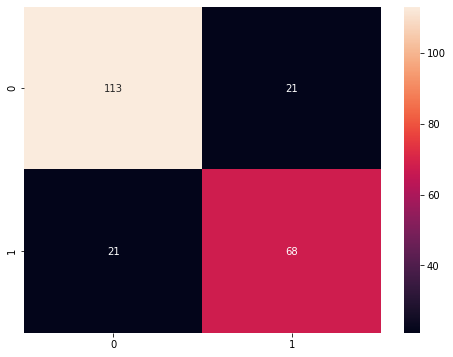

In [16]:
visualize_model(gbc_base)

### Searching for the best parameters

The GradientBoostingClassifier has the following parameters:
* `n_estimators`: int, default 100. The number of boosting stages to perform. Gradient boosting is fairly robust to over-fitting so a large number usually results in better performance.
* `learning_rate`: float, default 0.1. Learning rate shrinks the contribution of each tree by `learning_rate`. There is a trade-off between learning_rate and n_estimators.
* `criterion`: {‘friedman_mse’, ‘mse’, ‘mae’}, default ‘friedman_mse’. The function to measure the quality of a split.
* `loss`: {‘deviance’, ‘exponential’}, default ‘deviance’. The loss function to use when doing regression.
* `max_depth`: int, default 3. Maximum depth of the individual regression estimators. The maximum depth limits the number of nodes in the tree. Tune this parameter for best performance; the best value depends on the interaction of the input variables.
* `min_samples_split`: int, default 2. The minimum number of samples required to split an internal node.
* `min_samples_leaf`: int, default 1. The minimum number of samples required to be at a leaf node.
* `min_impurity_decrease`: float, default 0.0. A node will be split if this split induces a decrease of the impurity greater than or equal to this value.
* `max_features`: int, float, string or None, default ‘auto’. The number of features to consider when looking for the best split:
    - If int, then consider `max_features` features at each split.
    - If float, then `max_features` is a percentage and a random number of features are considered at each split.
    - If “auto”, then `max_features=sqrt(n_features)`.
    - If “sqrt”, then `max_features=sqrt(n_features)`.
    - If “log2”, then `max_features=log2(n_features)`.
    - If None, then `max_features=n_features`.


In [ ]:
all_params = {'n_estimators': [40, 50, 60,70,80],
    'learning_rate': [0.1, 0.2, 0.3, 0.4, 0.5],
    'criterion': ['friedman_mse', 'mse', 'mae'],
    'loss': ['deviance', 'exponential'],
    'max_depth': [2, 4, 6, 8, 10, 12],
    'min_samples_split': [2, 4, 6, 8, 10, 12],
    'min_samples_leaf': [1, 2, 4, 6, 8, 10],
    'max_features': ['auto', 'sqrt', 'log2', None],
    'min_impurity_decrease': [0.0, 0.1, 0.2, 0.3, 0.4, 0.5],
}

Since there are tons of hyperparameters to tune, we'll just search a subset of them.

In [ ]:
params = {'n_estimators': [40, 50, 60,70,80],
    'learning_rate': [0.1, 0.2, 0.3, 0.4, 0.5],
    'criterion': ['friedman_mse', 'mse', 'mae'],
    'max_depth': [2, 4, 6, 8, 10, 12],
    'min_samples_split': [2, 4, 6, 8, 10, 12],
    'min_samples_leaf': [1, 2, 4, 6, 8, 10],
    'max_features': ['auto'],
}

gbc_base = GradientBoostingClassifier(random_state=101)
grid_10 = perform_grid_search(gbc_base, params, text = True, play = False, verbose=1, cv = 3, n_jobs = 4)

Fitting 3 folds for each of 16200 candidates, totalling 48600 fits


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  48 tasks      | elapsed:    5.6s
[Parallel(n_jobs=4)]: Done 644 tasks      | elapsed:   16.2s
[Parallel(n_jobs=4)]: Done 1644 tasks      | elapsed:   50.4s
[Parallel(n_jobs=4)]: Done 2024 tasks      | elapsed:  1.2min
[Parallel(n_jobs=4)]: Done 2474 tasks      | elapsed:  1.6min
[Parallel(n_jobs=4)]: Done 3024 tasks      | elapsed:  2.3min
[Parallel(n_jobs=4)]: Done 4080 tasks      | elapsed:  2.9min
[Parallel(n_jobs=4)]: Done 5580 tasks      | elapsed:  4.0min
[Parallel(n_jobs=4)]: Done 6752 tasks      | elapsed:  5.2min
[Parallel(n_jobs=4)]: Done 8652 tasks      | elapsed:  6.5min
[Parallel(n_jobs=4)]: Done 10216 tasks      | elapsed:  8.0min
[Parallel(n_jobs=4)]: Done 12228 tasks      | elapsed:  9.9min
  0%|          | 0/5 [15:40<?, ?it/s]
[Parallel(n_jobs=4)]: Done 14710 tasks      | elapsed: 11.8min
[Parallel(n_jobs=4)]: Done 16060 tasks      | elapsed: 13.4min
[Parallel(n_jobs=

SMa8f34fe583214ed0be89dad476ea1021
Following is the best model and its parameters:
    Best Model:
GradientBoostingClassifier(learning_rate=0.2, max_depth=2, max_features='auto',
                           min_samples_leaf=4, min_samples_split=12,
                           n_estimators=40, random_state=101)
Best params:
    
{'criterion': 'friedman_mse', 'learning_rate': 0.2, 'max_depth': 2, 'max_features': 'auto', 'min_samples_leaf': 4, 'min_samples_split': 12, 'n_estimators': 40}
Best score: 0.8717132736387921


In [ ]:
params = {'n_estimators': [35,40,45],
    'learning_rate': [0.15, 0.2, 0.25],
    'criterion': ['friedman_mse'],
    'max_depth': [1, 2, 3],
    'min_samples_split': [3, 4, 5],
    'min_samples_leaf': [3, 4, 5],
    'max_features': ['auto'],
}

gbc_base = GradientBoostingClassifier(random_state=101)
grid_11 = perform_grid_search(gbc_base, params, text = False, play = False, verbose=1, cv = 3, n_jobs = 4)

Fitting 3 folds for each of 243 candidates, totalling 729 fits


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done 128 tasks      | elapsed:    1.8s


Following is the best model and its parameters:
    Best Model:
GradientBoostingClassifier(learning_rate=0.2, max_features='auto',
                           min_samples_leaf=3, min_samples_split=3,
                           n_estimators=35, random_state=101)
Best params:
    
{'criterion': 'friedman_mse', 'learning_rate': 0.2, 'max_depth': 3, 'max_features': 'auto', 'min_samples_leaf': 3, 'min_samples_split': 3, 'n_estimators': 35}
Best score: 0.874669762424137


[Parallel(n_jobs=4)]: Done 729 out of 729 | elapsed:   11.4s finished


In [ ]:
evaluate_model(grid_10.best_estimator_)

{'accuracy': 0.8340807174887892,
 'precision': 0.7888888888888889,
 'recall': 0.797752808988764,
 'f1': 0.7932960893854749,
 'roc_auc': 0.8279808821063224}

In [ ]:
evaluate_model(grid_11.best_estimator_)

{'accuracy': 0.8116591928251121,
 'precision': 0.7640449438202247,
 'recall': 0.7640449438202247,
 'f1': 0.7640449438202248,
 'roc_auc': 0.8036642629548886}

No improvement. Best model is:

In [19]:
parameters = {'criterion': 'friedman_mse', 'learning_rate': 0.2, 
'max_depth': 2, 'max_features': 'auto', 'min_samples_leaf': 4, 
'min_samples_split': 12, 'n_estimators': 40, 'random_state' :101}
gbc_final = GradientBoostingClassifier(**parameters)
gbc_final.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.2, max_depth=2, max_features='auto',
                           min_samples_leaf=4, min_samples_split=12,
                           n_estimators=40, random_state=101)

In [ ]:
gbc_final = grid_10.best_estimator_
evaluate_model(gbc_final, 'gbc_final', final = True)

{'accuracy': 0.8340807174887892,
 'precision': 0.7888888888888889,
 'recall': 0.797752808988764,
 'f1': 0.7932960893854749,
 'roc_auc': 0.8279808821063224}

              precision    recall  f1-score   support

           0       0.86      0.86      0.86       134
           1       0.79      0.80      0.79        89

    accuracy                           0.83       223
   macro avg       0.83      0.83      0.83       223
weighted avg       0.83      0.83      0.83       223



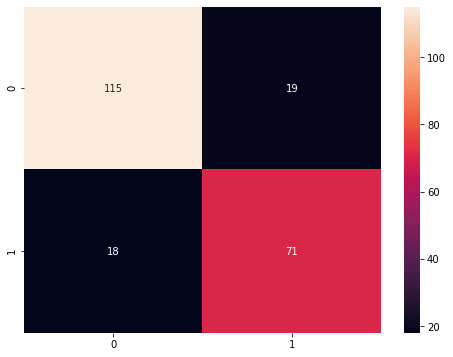

In [ ]:
visualize_model(gbc_final)

In [16]:
model_params["gbc_final"] = {'criterion': 'friedman_mse', 'learning_rate': 0.2, 
    'max_depth': 2, 'max_features': 'auto', 'min_samples_leaf': 4, 
    'min_samples_split': 12, 'n_estimators': 40, 'random_state' :101}

In [ ]:
pd.DataFrame(models_performance).T

,accuracy,precision,recall,f1,roc_auc
lr_base,0.802691,0.747253,0.764045,0.755556,0.796202
lr_gs_final,0.820628,0.769231,0.786517,0.777778,0.814900
knc_base,0.816143,0.779070,0.752809,0.765714,0.805509
knn_final,0.838565,0.844156,0.730337,0.783133,0.820392
svc_base,0.834081,0.817073,0.752809,0.783626,0.820434
svc_final,0.816143,0.785714,0.741573,0.763006,0.803622
dt_base,0.780269,0.708333,0.764045,0.735135,0.777545
dt_final,0.829596,0.800000,0.764045,0.781609,0.818590
rf_base,0.816143,0.766667,0.775281,0.770950,0.809282
rf_final,0.820628,0.802469,0.730337,0.764706,0.805467


## XGBClassifier

### Default Parameters

In [17]:
from xgboost import XGBClassifier
xgb_base = XGBClassifier(use_label_encoder=False)
xgb_base.fit(X_train, y_train)

[16:16:02] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
              gamma=0, gpu_id=-1, importance_type=None,
              interaction_constraints='', learning_rate=0.300000012,
              max_delta_step=0, max_depth=6, min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=100, n_jobs=8,
              num_parallel_tree=1, predictor='auto', random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
              tree_method='exact', use_label_encoder=False,
              validate_parameters=1, verbosity=None)

In [19]:
model_params["xgb_base"] =  xgb_base.get_params()

In [35]:
evaluate_model(xgb_base, 'sgb_base', final=True)

{'accuracy': 0.8340807174887892,
 'precision': 0.7888888888888889,
 'recall': 0.797752808988764,
 'f1': 0.7932960893854749,
 'roc_auc': 0.8279808821063224}

In [14]:
evaluate_model(xgb_base, 'sgb_base', final=True,
    train = True, X = X_train, y = y_train)

{'accuracy': 0.9820359281437125,
 'precision': 0.9878542510121457,
 'recall': 0.9644268774703557,
 'f1': 0.976,
 'roc_auc': 0.9785989809038526}

### Searching for best parameters

The XGBClassifier has almost same parameters as the `GradientBoostingClassifier`. We'll be using this. Some different parameters are:
* `booster`: {‘gbtree’, ‘gblinear’, ‘dart’}, default ‘gbtree’. The tree algorithm used.
* `min_child_weight`: int, default 1. Minimum sum of instance weight(hessian) needed in a child.
* `max_delta_step`: int, default 0. Maximum delta step we allow each tree’s weight estimation to be.
* `subsample`: float, default 1.0. Subsample ratio of the training instances.
* `colsample_bytree`: float, default 1.0. Subsample ratio of columns when constructing each tree.
* `colsample_bylevel`: float, default 1.0. Subsample ratio of columns for each split, in each level.
* `gamma`: float, default 0.0. Minimum loss reduction required to make a further partition on a leaf node of the tree.
* `reg_alpha`: float, default 0.0. L1 regularization term on weights.
* `reg_lambda`: float, default 1.0. L2 regularization term on weights.


Since the hyperparameter space is huge, we'll be using a subset of them.

In [38]:
params = {'n_estimators': [50,100,150],
    'learning_rate': [0.1, 0.4, 0.8],
    'max_depth': [4, 8, 16],
    'min_child_weight': [1, 3, 5],
    'gamma': [0.0, 0.5, 0.9],
    'reg_alpha': [0.0, 0.5, 0.9],
    'reg_lambda': [0.0, 0.5, 0.9],
    'subsample':[0.5, 0.9],
}

xgb_base = XGBClassifier(random_state=101)
grid_10 = perform_grid_search(xgb_base, params, text = True, play = False, verbose=1, cv = 3, n_jobs = 4)

Fitting 3 folds for each of 4374 candidates, totalling 13122 fits


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    4.9s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:   19.1s
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:   44.3s
[Parallel(n_jobs=4)]: Done 792 tasks      | elapsed:  1.4min
[Parallel(n_jobs=4)]: Done 1242 tasks      | elapsed:  2.9min
[Parallel(n_jobs=4)]: Done 1792 tasks      | elapsed:  3.6min
[Parallel(n_jobs=4)]: Done 2442 tasks      | elapsed:  4.4min
[Parallel(n_jobs=4)]: Done 3192 tasks      | elapsed:  5.3min
[Parallel(n_jobs=4)]: Done 4042 tasks      | elapsed:  6.4min
[Parallel(n_jobs=4)]: Done 4992 tasks      | elapsed:  7.7min
[Parallel(n_jobs=4)]: Done 6042 tasks      | elapsed:  9.3min
[Parallel(n_jobs=4)]: Done 7192 tasks      | elapsed: 10.8min
[Parallel(n_jobs=4)]: Done 8442 tasks      | elapsed: 12.5min
[Parallel(n_jobs=4)]: Done 9792 tasks      | elapsed: 14.8min
[Parallel(n_jobs=4)]: Done 11242 tasks      | elapsed: 17.3mi

[20:49:17] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
SMbae173c1c20240949f97b7cd745dc73c
Following is the best model and its parameters:
Best Model:
XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
              gamma=0.9, gpu_id=-1, importance_type=None,
              interaction_constraints='', learning_rate=0.8, max_delta_step=0,
              max_depth=4, min_child_weight=5, missing=nan,
              monotone_constraints='()', n_estimators=150, n_jobs=8,
              num_parallel_tree=1, predictor='auto', random_state=101,
              reg_alpha=0.5, reg_lambda=0.9, scale_pos_weight=1, subsample=0.9,
              tree_method='ex

In [16]:
params = {'n_estimators': [250,300,350],
    'learning_rate': [0.2 ,0.4,0.6],
    'max_depth': [3,4],
    'min_child_weight': [3,4],
    'gamma': [0.7,0.8, 0.9],
    'reg_alpha': [0.8, 0.9,1.0],
    'reg_lambda': [0.8, 0.9,1.0],
    'subsample':[ 0.9,1],
}

xgb_base = XGBClassifier(random_state=101)
grid_10 = perform_grid_search(xgb_base, params, text = True, 
    play = False, verbose=1, cv = 3, n_jobs = 4)

Fitting 3 folds for each of 1944 candidates, totalling 5832 fits


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    9.6s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:   31.9s
[Parallel(n_jobs=4)]: Done 442 tasks      | elapsed:  1.2min
[Parallel(n_jobs=4)]: Done 792 tasks      | elapsed:  2.9min
[Parallel(n_jobs=4)]: Done 1242 tasks      | elapsed:  6.2min
[Parallel(n_jobs=4)]: Done 1792 tasks      | elapsed:  8.4min
[Parallel(n_jobs=4)]: Done 2442 tasks      | elapsed: 11.4min
[Parallel(n_jobs=4)]: Done 3192 tasks      | elapsed: 14.6min
[Parallel(n_jobs=4)]: Done 4042 tasks      | elapsed: 18.4min
[Parallel(n_jobs=4)]: Done 4992 tasks      | elapsed: 22.8min
[Parallel(n_jobs=4)]: Done 5832 out of 5832 | elapsed: 26.1min finished
C:\Users\harik\anaconda3\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option us

[08:29:40] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
SM14927b18d00e49aeb4faf57c481b1fc2
Following is the best model and its parameters:
Best Model:
XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
              gamma=0.9, gpu_id=-1, importance_type=None,
              interaction_constraints='', learning_rate=0.6, max_delta_step=0,
              max_depth=4, min_child_weight=4, missing=nan,
              monotone_constraints='()', n_estimators=250, n_jobs=8,
              num_parallel_tree=1, predictor='auto', random_state=101,
              reg_alpha=0.8, reg_lambda=0.8, scale_pos_weight=1, subsample=0.9,
              tree_method='ex

In [17]:
params = {'n_estimators': [230,240,250,260,270],
    'learning_rate': [0.5,0.6,0.7],
    'max_depth': [4],
    'min_child_weight': [4],
    'gamma': [0.8, 0.9],
    'reg_alpha': [0.8],
    'reg_lambda': [0.8],
    'subsample':[0.9],
}

xgb_base = XGBClassifier(random_state=101)
grid_11 = perform_grid_search(xgb_base, params, text = False, 
    play = False, verbose=1, cv = 3, n_jobs = 4)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:   18.8s
[Parallel(n_jobs=4)]: Done  90 out of  90 | elapsed:   29.6s finished
C:\Users\harik\anaconda3\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


[08:37:55] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
Following is the best model and its parameters:
Best Model:
XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
              gamma=0.9, gpu_id=-1, importance_type=None,
              interaction_constraints='', learning_rate=0.6, max_delta_step=0,
              max_depth=4, min_child_weight=4, missing=nan,
              monotone_constraints='()', n_estimators=230, n_jobs=8,
              num_parallel_tree=1, predictor='auto', random_state=101,
              reg_alpha=0.8, reg_lambda=0.8, scale_pos_weight=1, subsample=0.9,
              tree_method='exact', validate_parameters=1, verbos

In [19]:
params = {'n_estimators': [210,220,230],
    'learning_rate': [0.5,0.6,0.7],
    'max_depth': [4],
    'min_child_weight': [4],
    'gamma': [0.9],
    'reg_alpha': [0.8],
    'reg_lambda': [0.8],
    'subsample':[0.9],
}

xgb_base = XGBClassifier(random_state=101)
grid_11 = perform_grid_search(xgb_base, params, text = False, 
    play = False, verbose=1, cv = 3, n_jobs = 4)

Fitting 3 folds for each of 9 candidates, totalling 27 fits


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  27 out of  27 | elapsed:    7.7s finished
C:\Users\harik\anaconda3\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


[08:40:48] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
Following is the best model and its parameters:
Best Model:
XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, enable_categorical=False,
              gamma=0.9, gpu_id=-1, importance_type=None,
              interaction_constraints='', learning_rate=0.6, max_delta_step=0,
              max_depth=4, min_child_weight=4, missing=nan,
              monotone_constraints='()', n_estimators=230, n_jobs=8,
              num_parallel_tree=1, predictor='auto', random_state=101,
              reg_alpha=0.8, reg_lambda=0.8, scale_pos_weight=1, subsample=0.9,
              tree_method='exact', validate_parameters=1, verbos

This should be the final one.

In [25]:
parameters = {'gamma': 0.9, 'learning_rate': 0.6, 'max_depth': 4, 'min_child_weight': 4, 
    'n_estimators': 230, 'reg_alpha': 0.8, 'reg_lambda': 0.8, 'subsample': 0.9}
xgb_final = XGBClassifier(random_state = 101, **parameters)

In [23]:
xgb_final = grid_11.best_estimator_
evaluate_model(xgb_final, 'xgb_final', final = True)

{'accuracy': 0.8116591928251121,
 'precision': 0.7582417582417582,
 'recall': 0.7752808988764045,
 'f1': 0.7666666666666667,
 'roc_auc': 0.8055508971993962}

In [21]:
evaluate_model(xgb_final, 'xgb_final', final = True,
    train = True, X = X_train, y = y_train)

{'accuracy': 0.9206586826347305,
 'precision': 0.9385964912280702,
 'recall': 0.8458498023715415,
 'f1': 0.8898128898128898,
 'roc_auc': 0.9060574313062526}

In [20]:
model_params["xgb_final"] = {'gamma': 0.9, 'learning_rate': 0.6, 'max_depth': 4, 'min_child_weight': 4, 
    'n_estimators': 230, 'reg_alpha': 0.8, 'reg_lambda': 0.8, 'subsample': 0.9}

## AdaBoostClassifier

### Default Parameters

In [21]:
from sklearn.ensemble import AdaBoostClassifier
ada_base = AdaBoostClassifier(random_state=101)
ada_base.fit(X_train, y_train)
evaluate_model(ada_base, 'ada_base', final=True)

{'accuracy': 0.820627802690583,
 'precision': 0.7578947368421053,
 'recall': 0.8089887640449438,
 'f1': 0.782608695652174,
 'roc_auc': 0.818673486500084}

In [22]:
model_params["ada_base"] = ada_base.get_params()

              precision    recall  f1-score   support

           0       0.87      0.83      0.85       134
           1       0.76      0.81      0.78        89

    accuracy                           0.82       223
   macro avg       0.81      0.82      0.81       223
weighted avg       0.82      0.82      0.82       223



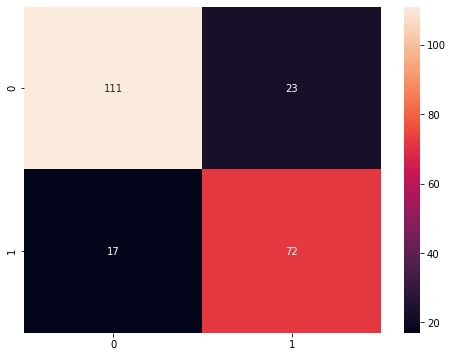

In [34]:
visualize_model(ada_base)

In [35]:
evaluate_model(ada_base, 'ada_base', final=True,
    train = True, X = X_train, y = y_train)

{'accuracy': 0.8547904191616766,
 'precision': 0.819672131147541,
 'recall': 0.7905138339920948,
 'f1': 0.8048289738430584,
 'roc_auc': 0.8422448688032763}

### Searching for best parameters

Some of the parameters are:
* `n_estimators`: int, default 50. The number of boosting stages to perform.
* `learning_rate`: float, default 1. The learning rate shrinks the contribution of each tree by `learning_rate`. There is a trade-off between learning_rate and n_estimators.
* `algorithm`: {‘SAMME’, ‘SAMME.R’}, default ‘SAMME.R’. If ‘SAMME.R’, then use the SAMME.R real boosting algorithm.


In [36]:
params = {'n_estimators': [50,100,150],
    'learning_rate': [0.1, 0.4, 0.8],
    'algorithm': ['SAMME', 'SAMME.R'],
}
ada_base = AdaBoostClassifier(random_state=101)
grid_12 = perform_grid_search(ada_base, params, text = False,
    play = True, verbose=1, cv = 3, n_jobs = 4)

Fitting 3 folds for each of 18 candidates, totalling 54 fits


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:   14.1s
[Parallel(n_jobs=4)]: Done  54 out of  54 | elapsed:   15.6s finished


Following is the best model and its parameters:
Best Model:
AdaBoostClassifier(learning_rate=0.1, n_estimators=150, random_state=101)
Best params:
{'algorithm': 'SAMME.R', 'learning_rate': 0.1, 'n_estimators': 150}
Best score: 0.8663038513288748


In [37]:
evaluate_model(grid_12.best_estimator_)

{'accuracy': 0.8026905829596412,
 'precision': 0.7528089887640449,
 'recall': 0.7528089887640449,
 'f1': 0.752808988764045,
 'roc_auc': 0.7943149421432164}

In [40]:
params = {'n_estimators': [130,150, 200,250],
    'learning_rate': [0.1,0.2,0.3],
    'algorithm': ['SAMME.R'],
}
ada_base = AdaBoostClassifier(random_state=101)
grid_13 = perform_grid_search(ada_base, params, text = False,
    play = False, verbose=1, cv = 3, n_jobs = 4)

evaluate_model(grid_13.best_estimator_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  36 out of  36 | elapsed:   14.9s finished


Following is the best model and its parameters:
Best Model:
AdaBoostClassifier(learning_rate=0.1, n_estimators=130, random_state=101)
Best params:
{'algorithm': 'SAMME.R', 'learning_rate': 0.1, 'n_estimators': 130}
Best score: 0.866782383373535


{'accuracy': 0.8116591928251121,
 'precision': 0.7701149425287356,
 'recall': 0.7528089887640449,
 'f1': 0.7613636363636362,
 'roc_auc': 0.8017776287103806}

In [41]:
params = {'n_estimators': [110, 120,130,140],
    'learning_rate': [0.1],
    'algorithm': ['SAMME.R'],
}
ada_base = AdaBoostClassifier(random_state=101)
grid_13 = perform_grid_search(ada_base, params, text = False,
    play = False, verbose=1, cv = 3, n_jobs = 4)

evaluate_model(grid_13.best_estimator_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  12 out of  12 | elapsed:    2.5s finished


Following is the best model and its parameters:
Best Model:
AdaBoostClassifier(learning_rate=0.1, n_estimators=110, random_state=101)
Best params:
{'algorithm': 'SAMME.R', 'learning_rate': 0.1, 'n_estimators': 110}
Best score: 0.8706769707848384


{'accuracy': 0.8116591928251121,
 'precision': 0.7701149425287356,
 'recall': 0.7528089887640449,
 'f1': 0.7613636363636362,
 'roc_auc': 0.8017776287103806}

This is final.

In [42]:
ada_final = grid_13.best_estimator_
evaluate_model(ada_final, 'ada_final', final = True)

{'accuracy': 0.8116591928251121,
 'precision': 0.7701149425287356,
 'recall': 0.7528089887640449,
 'f1': 0.7613636363636362,
 'roc_auc': 0.8017776287103806}

In [43]:
evaluate_model(ada_final, 'ada_final', final = True,
    train = True, X = X_train, y = y_train)

{'accuracy': 0.842814371257485,
 'precision': 0.8109243697478992,
 'recall': 0.7628458498023716,
 'f1': 0.7861507128309573,
 'roc_auc': 0.8272060574313063}

In [23]:
model_params["ada_final"] ={'algorithm': 'SAMME.R', 'learning_rate': 0.1, 'n_estimators': 110}

## BaggingClassifier

### Default Parameters

In [24]:
from sklearn.ensemble import BaggingClassifier
bagging_base = BaggingClassifier(random_state=101)
bagging_base.fit(X_train, y_train)
evaluate_model(bagging_base, 'bagging_base', final = True)

{'accuracy': 0.8116591928251121,
 'precision': 0.7901234567901234,
 'recall': 0.7191011235955056,
 'f1': 0.7529411764705881,
 'roc_auc': 0.7961177259768573}

In [25]:
model_params["bagging_base"] = bagging_base.get_params()

              precision    recall  f1-score   support

           0       0.82      0.87      0.85       134
           1       0.79      0.72      0.75        89

    accuracy                           0.81       223
   macro avg       0.81      0.80      0.80       223
weighted avg       0.81      0.81      0.81       223



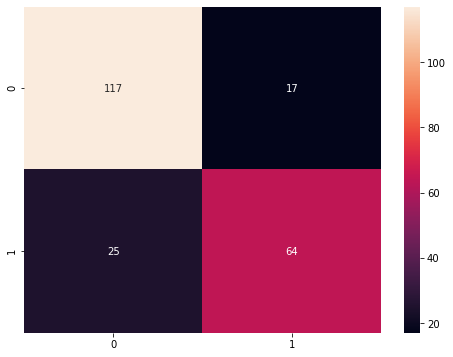

In [16]:
visualize_model(bagging_base)

In [17]:
evaluate_model(bagging_base, 'bagging_base', final = True,
    train = True, X = X_train, y = y_train)

{'accuracy': 0.9715568862275449,
 'precision': 0.9875,
 'recall': 0.9367588932806324,
 'f1': 0.9614604462474645,
 'roc_auc': 0.9647649888089909}

### Searching for best parameters

#### Parameters

The parameters for the BaggingClassifier are:
* `n_estimators`: int, default 10. The number of base estimators in the ensemble.
* `base_estimator`: object, default None. The base estimator from which the boosted ensemble is built.
* `max_samples`: int, default 1. The number of samples to draw from X to train each base estimator.
* `max_features`: int, float. The number of features to consider when looking for the best split:
    - If int, then consider `max_features` features at each split.
    - If float, then `max_features` is a percentage and a random number of features are considered at each split.
    - If float, then draw `max_features * X.shape[1]` features.
* `bootstrap`: boolean, default True. Whether samples are drawn with replacement.
* `bootstrap_features`: boolean, default False. Whether features are drawn with replacement.
* `oob_score`: bool, default False. Whether to use out-of-bag samples to estimate the R^2 on unseen data.

In [50]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
params = {'base_estimator': [XGBClassifier(), GradientBoostingClassifier(), 
    DecisionTreeClassifier(), RandomForestClassifier(), AdaBoostClassifier()],
    'max_samples': [0.3, 0.5, 0.7, 1.0],
    'max_features': [0.3, 0.5, 0.7, 1.0],
    'bootstrap_features': [True, False],
    'oob_score': [True, False],
}

bagging_base = BaggingClassifier(random_state=101)
grid_14 = perform_grid_search(bagging_base, params, text = True,
    play = False, verbose=1, cv = 3, n_jobs = 4)

Fitting 3 folds for each of 320 candidates, totalling 960 fits


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:   39.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:  2.9min
[Parallel(n_jobs=4)]: Done 472 tasks      | elapsed:  4.2min
[Parallel(n_jobs=4)]: Done 884 tasks      | elapsed:  8.5min
[Parallel(n_jobs=4)]: Done 960 out of 960 | elapsed:  9.1min finished


SM5d0756bdcf0248a39483b8db01c8e59a
Following is the best model and its parameters:
Best Model:
BaggingClassifier(base_estimator=GradientBoostingClassifier(),
                  bootstrap_features=True, max_samples=0.5, oob_score=True,
                  random_state=101)
Best params:
{'base_estimator': GradientBoostingClassifier(), 'bootstrap_features': True, 'max_features': 1.0, 'max_samples': 0.5, 'oob_score': True}
Best score: 0.8761878549772532


In [51]:
evaluate_model(grid_14.best_estimator_)

{'accuracy': 0.8340807174887892,
 'precision': 0.8023255813953488,
 'recall': 0.7752808988764045,
 'f1': 0.7885714285714286,
 'roc_auc': 0.8242076136173067}

So, `GradientBoostingClassifier` is the best model. Let's try to narrow down the hyperparameter space.

In [25]:
params = {'base_estimator': [GradientBoostingClassifier()],
    'max_samples': [0.4, 0.5,0.6],
    'max_features': [0.9,1.0],
    'bootstrap_features': [True],
    'oob_score': [True],
}

bagging_base = BaggingClassifier(random_state=101)
grid_11 = perform_grid_search(bagging_base, params, text = False,
    play = False, verbose=1, cv = 3, n_jobs = 2)

Fitting 3 folds for each of 6 candidates, totalling 18 fits


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  18 out of  18 | elapsed:   13.1s finished


Following is the best model and its parameters:
Best Model:
BaggingClassifier(base_estimator=GradientBoostingClassifier(),
                  bootstrap_features=True, max_samples=0.5, oob_score=True,
                  random_state=101)
Best params:
{'base_estimator': GradientBoostingClassifier(), 'bootstrap_features': True, 'max_features': 1.0, 'max_samples': 0.5, 'oob_score': True}
Best score: 0.8761878549772532


Let's optimize the `n_estimators` parameter.

In [29]:
params = {'n_estimators': [10,20,30,40,50],
    'base_estimator': [GradientBoostingClassifier()],
    'max_samples': [0.5],
    'max_features': [1.0],
    'bootstrap_features': [True],
    'oob_score': [True],
}

bagging_base = BaggingClassifier(random_state=101)
grid_11 = perform_grid_search(bagging_base, params, text = False,
    play = True, verbose=1, cv = 3, n_jobs = 2)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  15 out of  15 | elapsed:   25.0s finished


Following is the best model and its parameters:
Best Model:
BaggingClassifier(base_estimator=GradientBoostingClassifier(),
                  bootstrap_features=True, max_samples=0.5, oob_score=True,
                  random_state=101)
Best params:
{'base_estimator': GradientBoostingClassifier(), 'bootstrap_features': True, 'max_features': 1.0, 'max_samples': 0.5, 'n_estimators': 10, 'oob_score': True}
Best score: 0.8761878549772532


So, the previous models should be the final.

In [27]:
bagging_final = grid_11.best_estimator_
evaluate_model(bagging_final, 'bagging_final', final = True)

{'accuracy': 0.8340807174887892,
 'precision': 0.8023255813953488,
 'recall': 0.7752808988764045,
 'f1': 0.7885714285714286,
 'roc_auc': 0.8242076136173067}

In [28]:
evaluate_model(bagging_final, 'bagging_final', final = True,
    train = True, X = X_train, y = y_train)

{'accuracy': 0.8787425149700598,
 'precision': 0.8873873873873874,
 'recall': 0.7786561264822134,
 'f1': 0.8294736842105263,
 'roc_auc': 0.8592075813133958}

So, the bagging model with DescisionTreeClassifier as base estimator is performing better than the bagging model with RandomForestClassifier as base estimator.

In [26]:
model_params['bagging_final'] = {'base_estimator': GradientBoostingClassifier(), 'bootstrap_features': True, 
    'max_features': 1.0, 'max_samples': 0.5, 'n_estimators': 10, 'oob_score': True}

## ExtraTreesClassifier

### Default Parameters

In [27]:
from sklearn.ensemble import ExtraTreesClassifier
etc_base = ExtraTreesClassifier(random_state=101)
etc_base.fit(X_train, y_train)
evaluate_model(etc_base, 'etc_base', final = True)

{'accuracy': 0.7937219730941704,
 'precision': 0.7263157894736842,
 'recall': 0.7752808988764045,
 'f1': 0.7500000000000001,
 'roc_auc': 0.7906255240650679}

In [28]:
model_params["etc_base"] = etc_base.get_params()

### Searching for best parameters

The parameters for the ExtraTreesClassifier are similar to the `DecisionTreeClassifier`. like:
* `n_estimators`: int, default 100. The number of trees in the forest.
* `criterion`: {‘gini’, ‘entropy’}, default ‘gini’. The function to measure the quality of a split.
* `max_depth`: int, default None. The maximum depth of the tree. If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples.
* `min_samples_split`: int, default 2. The minimum number of samples required to split an internal node.
etc.

In [53]:
params = {'n_estimators': [20,50,100],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 2, 4, 6, 8, 10],
    'max_features': [0.3, 0.5, 0.7, 1.0],
    'min_samples_split': [2, 3, 4, 5, 6, 7, 8],
    'min_samples_leaf': [1, 2, 3, 4, 5, 6, 7],
}
etc_base = ExtraTreesClassifier(random_state=101)
grid_15 = perform_grid_search(etc_base, params, text = True,
    play = False, verbose=1, cv = 3, n_jobs = 2)

Fitting 3 folds for each of 7056 candidates, totalling 21168 fits


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    6.5s
[Parallel(n_jobs=2)]: Done 306 tasks      | elapsed:   22.1s
[Parallel(n_jobs=2)]: Done 806 tasks      | elapsed:   54.3s
[Parallel(n_jobs=2)]: Done 1230 tasks      | elapsed:  1.7min
[Parallel(n_jobs=2)]: Done 2130 tasks      | elapsed:  2.5min
[Parallel(n_jobs=2)]: Done 3230 tasks      | elapsed:  3.4min
[Parallel(n_jobs=2)]: Done 4530 tasks      | elapsed:  4.5min
[Parallel(n_jobs=2)]: Done 6030 tasks      | elapsed:  6.0min
[Parallel(n_jobs=2)]: Done 7730 tasks      | elapsed:  7.7min
[Parallel(n_jobs=2)]: Done 9630 tasks      | elapsed:  9.6min
[Parallel(n_jobs=2)]: Done 11730 tasks      | elapsed: 11.9min
[Parallel(n_jobs=2)]: Done 14030 tasks      | elapsed: 14.2min
[Parallel(n_jobs=2)]: Done 16530 tasks      | elapsed: 16.7min
[Parallel(n_jobs=2)]: Done 19230 tasks      | elapsed: 19.6min
[Parallel(n_jobs=2)]: Done 21168 out of 21168 | elapsed:

SM0088b7073c594f8aba25a11e1fea9858
Following is the best model and its parameters:
Best Model:
ExtraTreesClassifier(criterion='entropy', max_depth=6, max_features=0.3,
                     min_samples_leaf=2, n_estimators=50, random_state=101)
Best params:
{'criterion': 'entropy', 'max_depth': 6, 'max_features': 0.3, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}
Best score: 0.8701184795678255


In [54]:
evaluate_model(grid_15.best_estimator_)

{'accuracy': 0.8295964125560538,
 'precision': 0.8,
 'recall': 0.7640449438202247,
 'f1': 0.7816091954022989,
 'roc_auc': 0.8185896360892169}

In [55]:
params = {'n_estimators': [30,40,50,60,70],
    'criterion': ['entropy'],
    'max_depth': [5, 6, 7],
    'max_features': [0.2, 0.3, 0.4],
    'min_samples_split': [1, 2, 3],
    'min_samples_leaf': [2],
}
etc_base = ExtraTreesClassifier(random_state=101)
grid_16 = perform_grid_search(etc_base, params, text = True,
    play = False, verbose=1, cv = 3, n_jobs = 2)

evaluate_model(grid_16.best_estimator_)

Fitting 3 folds for each of 135 candidates, totalling 405 fits


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done 164 tasks      | elapsed:    6.4s
[Parallel(n_jobs=2)]: Done 405 out of 405 | elapsed:   15.3s finished


SM73905fffd2174a50873155af9f26d7cd
Following is the best model and its parameters:
Best Model:
ExtraTreesClassifier(criterion='entropy', max_depth=6, max_features=0.3,
                     min_samples_leaf=2, n_estimators=70, random_state=101)
Best params:
{'criterion': 'entropy', 'max_depth': 6, 'max_features': 0.3, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 70}
Best score: 0.8701943608917518


{'accuracy': 0.8295964125560538,
 'precision': 0.8,
 'recall': 0.7640449438202247,
 'f1': 0.7816091954022989,
 'roc_auc': 0.8185896360892169}

In [56]:
params = {'n_estimators': [70,80,90],
    'criterion': ['entropy'],
    'max_depth': [6],
    'max_features': [0.3],
    'min_samples_split': [2],
    'min_samples_leaf': [2],
}
etc_base = ExtraTreesClassifier(random_state=101)
grid_17 = perform_grid_search(etc_base, params, text = False,
    play = False, verbose=1, cv = 3, n_jobs = 2)

evaluate_model(grid_17.best_estimator_)

Fitting 3 folds for each of 3 candidates, totalling 9 fits


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   6 out of   9 | elapsed:    0.6s remaining:    0.3s


Following is the best model and its parameters:
Best Model:
ExtraTreesClassifier(criterion='entropy', max_depth=6, max_features=0.3,
                     min_samples_leaf=2, n_estimators=80, random_state=101)
Best params:
{'criterion': 'entropy', 'max_depth': 6, 'max_features': 0.3, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 80}
Best score: 0.8702947044386168


[Parallel(n_jobs=2)]: Done   9 out of   9 | elapsed:    0.8s finished


{'accuracy': 0.8295964125560538,
 'precision': 0.8,
 'recall': 0.7640449438202247,
 'f1': 0.7816091954022989,
 'roc_auc': 0.8185896360892169}

This should be the final one.

In [57]:
etc_final = grid_17.best_estimator_
evaluate_model(etc_final, 'etc_final', final = True)

{'accuracy': 0.8295964125560538,
 'precision': 0.8,
 'recall': 0.7640449438202247,
 'f1': 0.7816091954022989,
 'roc_auc': 0.8185896360892169}

In [58]:
evaluate_model(etc_final, 'etc_final', final = True,
    train = True, X = X_train, y = y_train)

{'accuracy': 0.8592814371257484,
 'precision': 0.8533333333333334,
 'recall': 0.758893280632411,
 'f1': 0.803347280334728,
 'roc_auc': 0.8396876041716272}

              precision    recall  f1-score   support

           0       0.85      0.87      0.86       134
           1       0.80      0.76      0.78        89

    accuracy                           0.83       223
   macro avg       0.82      0.82      0.82       223
weighted avg       0.83      0.83      0.83       223



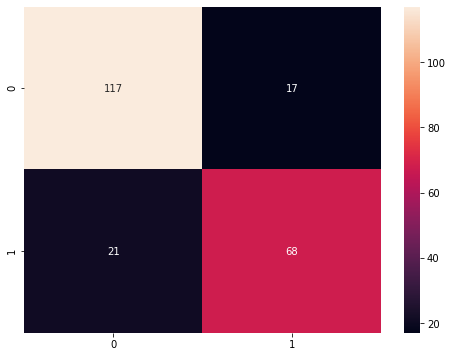

In [59]:
visualize_model(etc_final)

In [29]:
model_params["etc_final"] = {'criterion': 'entropy', 'max_depth': 6, 'max_features': 0.3, 
    'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 80}

In [30]:
model_params.close()